# INP浓度和降水量的时间序列 (2025.01)

可以改动的东西有: 温度(即选择不同温度下的INP浓度)和日期

## -15degC

In [2]:
## 导入相关库, 定义函数(用于数据处理)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

def compute_avg(s, round_index=True):
    """
    从 Series 中提取每段非 NaN 区间的尾值，并计算：
    - 尾值的平均
    - 索引平均（可选四舍五入）
    
    参数:
        s: pd.Series
        round_index : bool, 默认为 True, 是否对 index 均值四舍五入
    
    返回:
        pd.Series, 索引 = 平均 index, 值 = 平均尾值
        如果没有任何尾值，返回一个空 Series
    """

    ### 保证输入是 Series
    if not isinstance(s, pd.Series):
        raise TypeError("Input must be a pandas Series.")

    ### 1. 提取每段非 NaN 区间的尾值
    mask = s.notna() & s.shift(-1).isna()
    s_last = s[mask]

    ### 2. 如果没有尾值，返回空 Series
    if len(s_last) == 0:
        return pd.Series(np.nan, index=[np.mean(s.index)])

    ###3. 计算值和索引的均值
    value_mean = s_last.mean()
    index_mean = np.mean(s_last.index)

    if round_index:
        index_mean = int(round(index_mean))

    ### 4. 返回带“平均索引”的 Series
    return pd.Series(value_mean, index=[index_mean])


def compute_net(sam, bac):
    """
    输入两个时间序列, 先计算两者的均值, 再计算差值(采样值-背景值)
    
    参数:
        sam: pd.Series, 采样值时间序列
        bac: pd.Series, 背景值时间序列
    返回:
        pd.Series, 差值时间序列
        若差值小于0, 则返回0
    """
    sam_avg = compute_avg(sam)
    bac_avg = compute_avg(bac)

    ### 最终 index = 这两个均值索引的平均
    final_index = int(round((sam_avg.index[0] + bac_avg.index[0]) / 2))

    net = float(sam_avg.values[0] - bac_avg.values[0])

    return pd.Series(max(net, 0.0), index=[final_index])


In [21]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')

    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -15degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-15.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(N_inp_sam, N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index[0]])
    all_INP.append(N_inp_avg_net[N_inp_avg_net.index[0]])

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

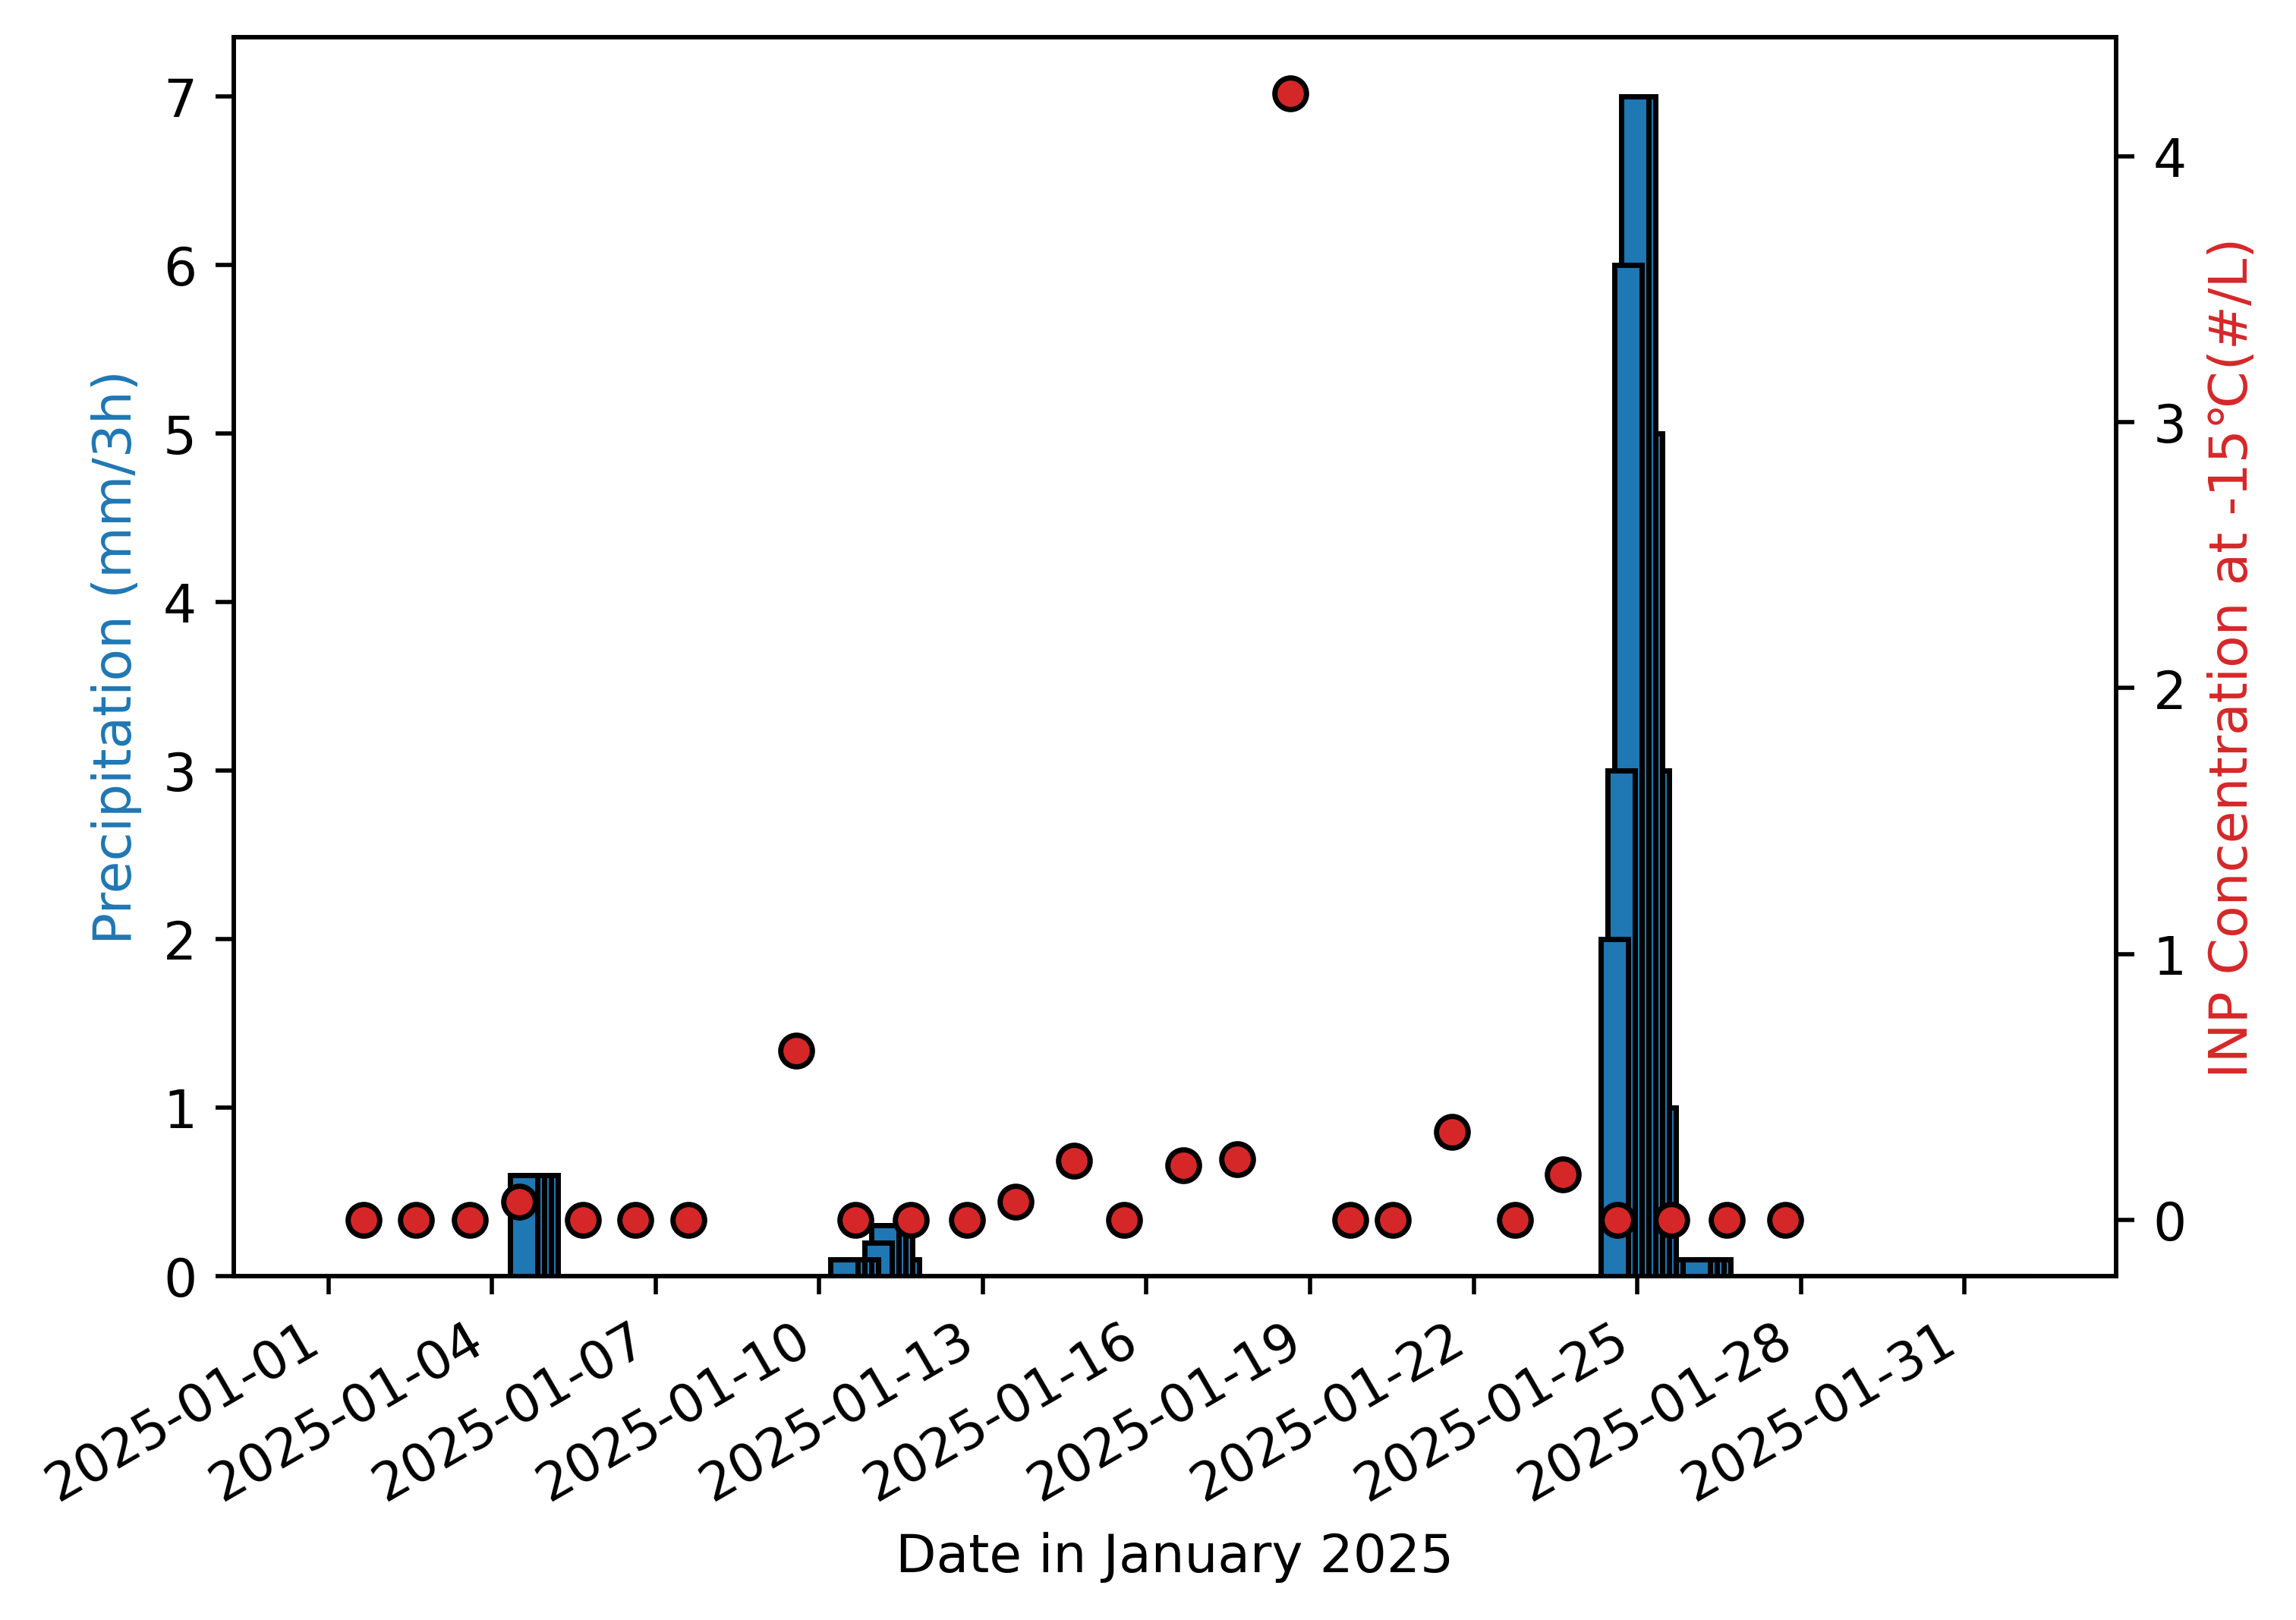

In [22]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -15℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-15_jan_linear.png")###

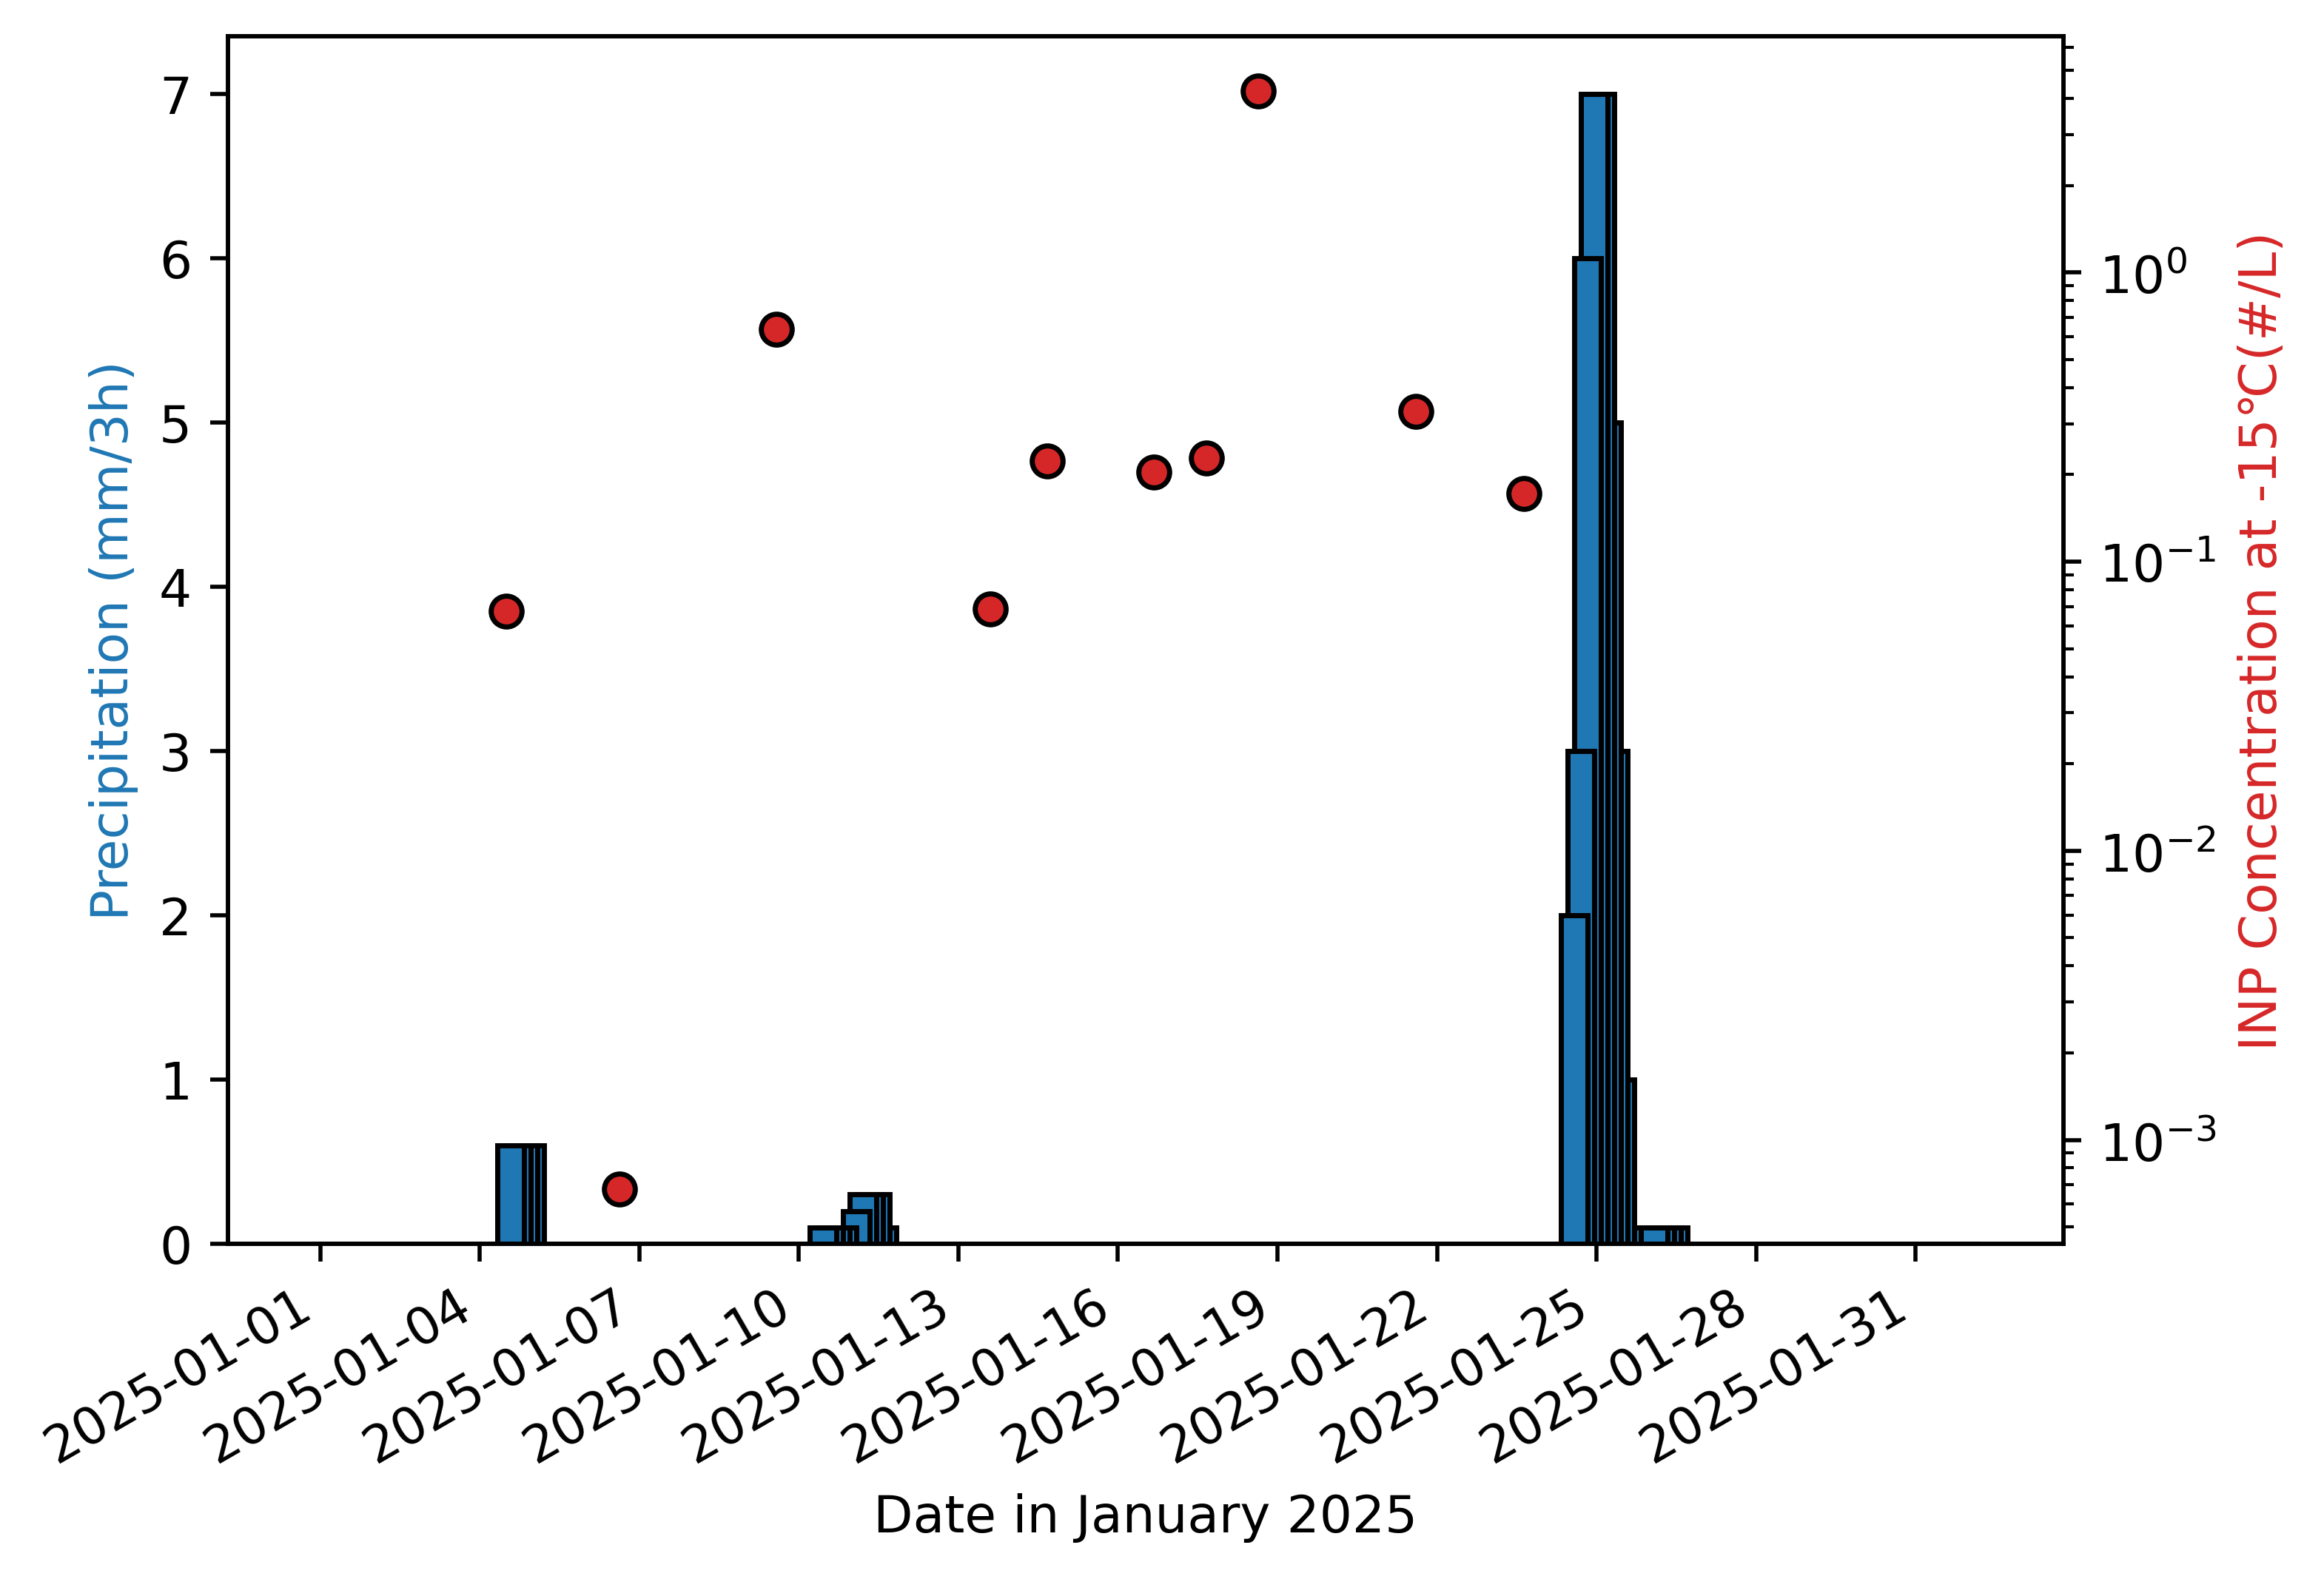

In [23]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -15℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-15_jan_log.png")###

## -20degC

In [24]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')

    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -20degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-20.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-20.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(N_inp_sam, N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index[0]])
    all_INP.append(N_inp_avg_net[N_inp_avg_net.index[0]])

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

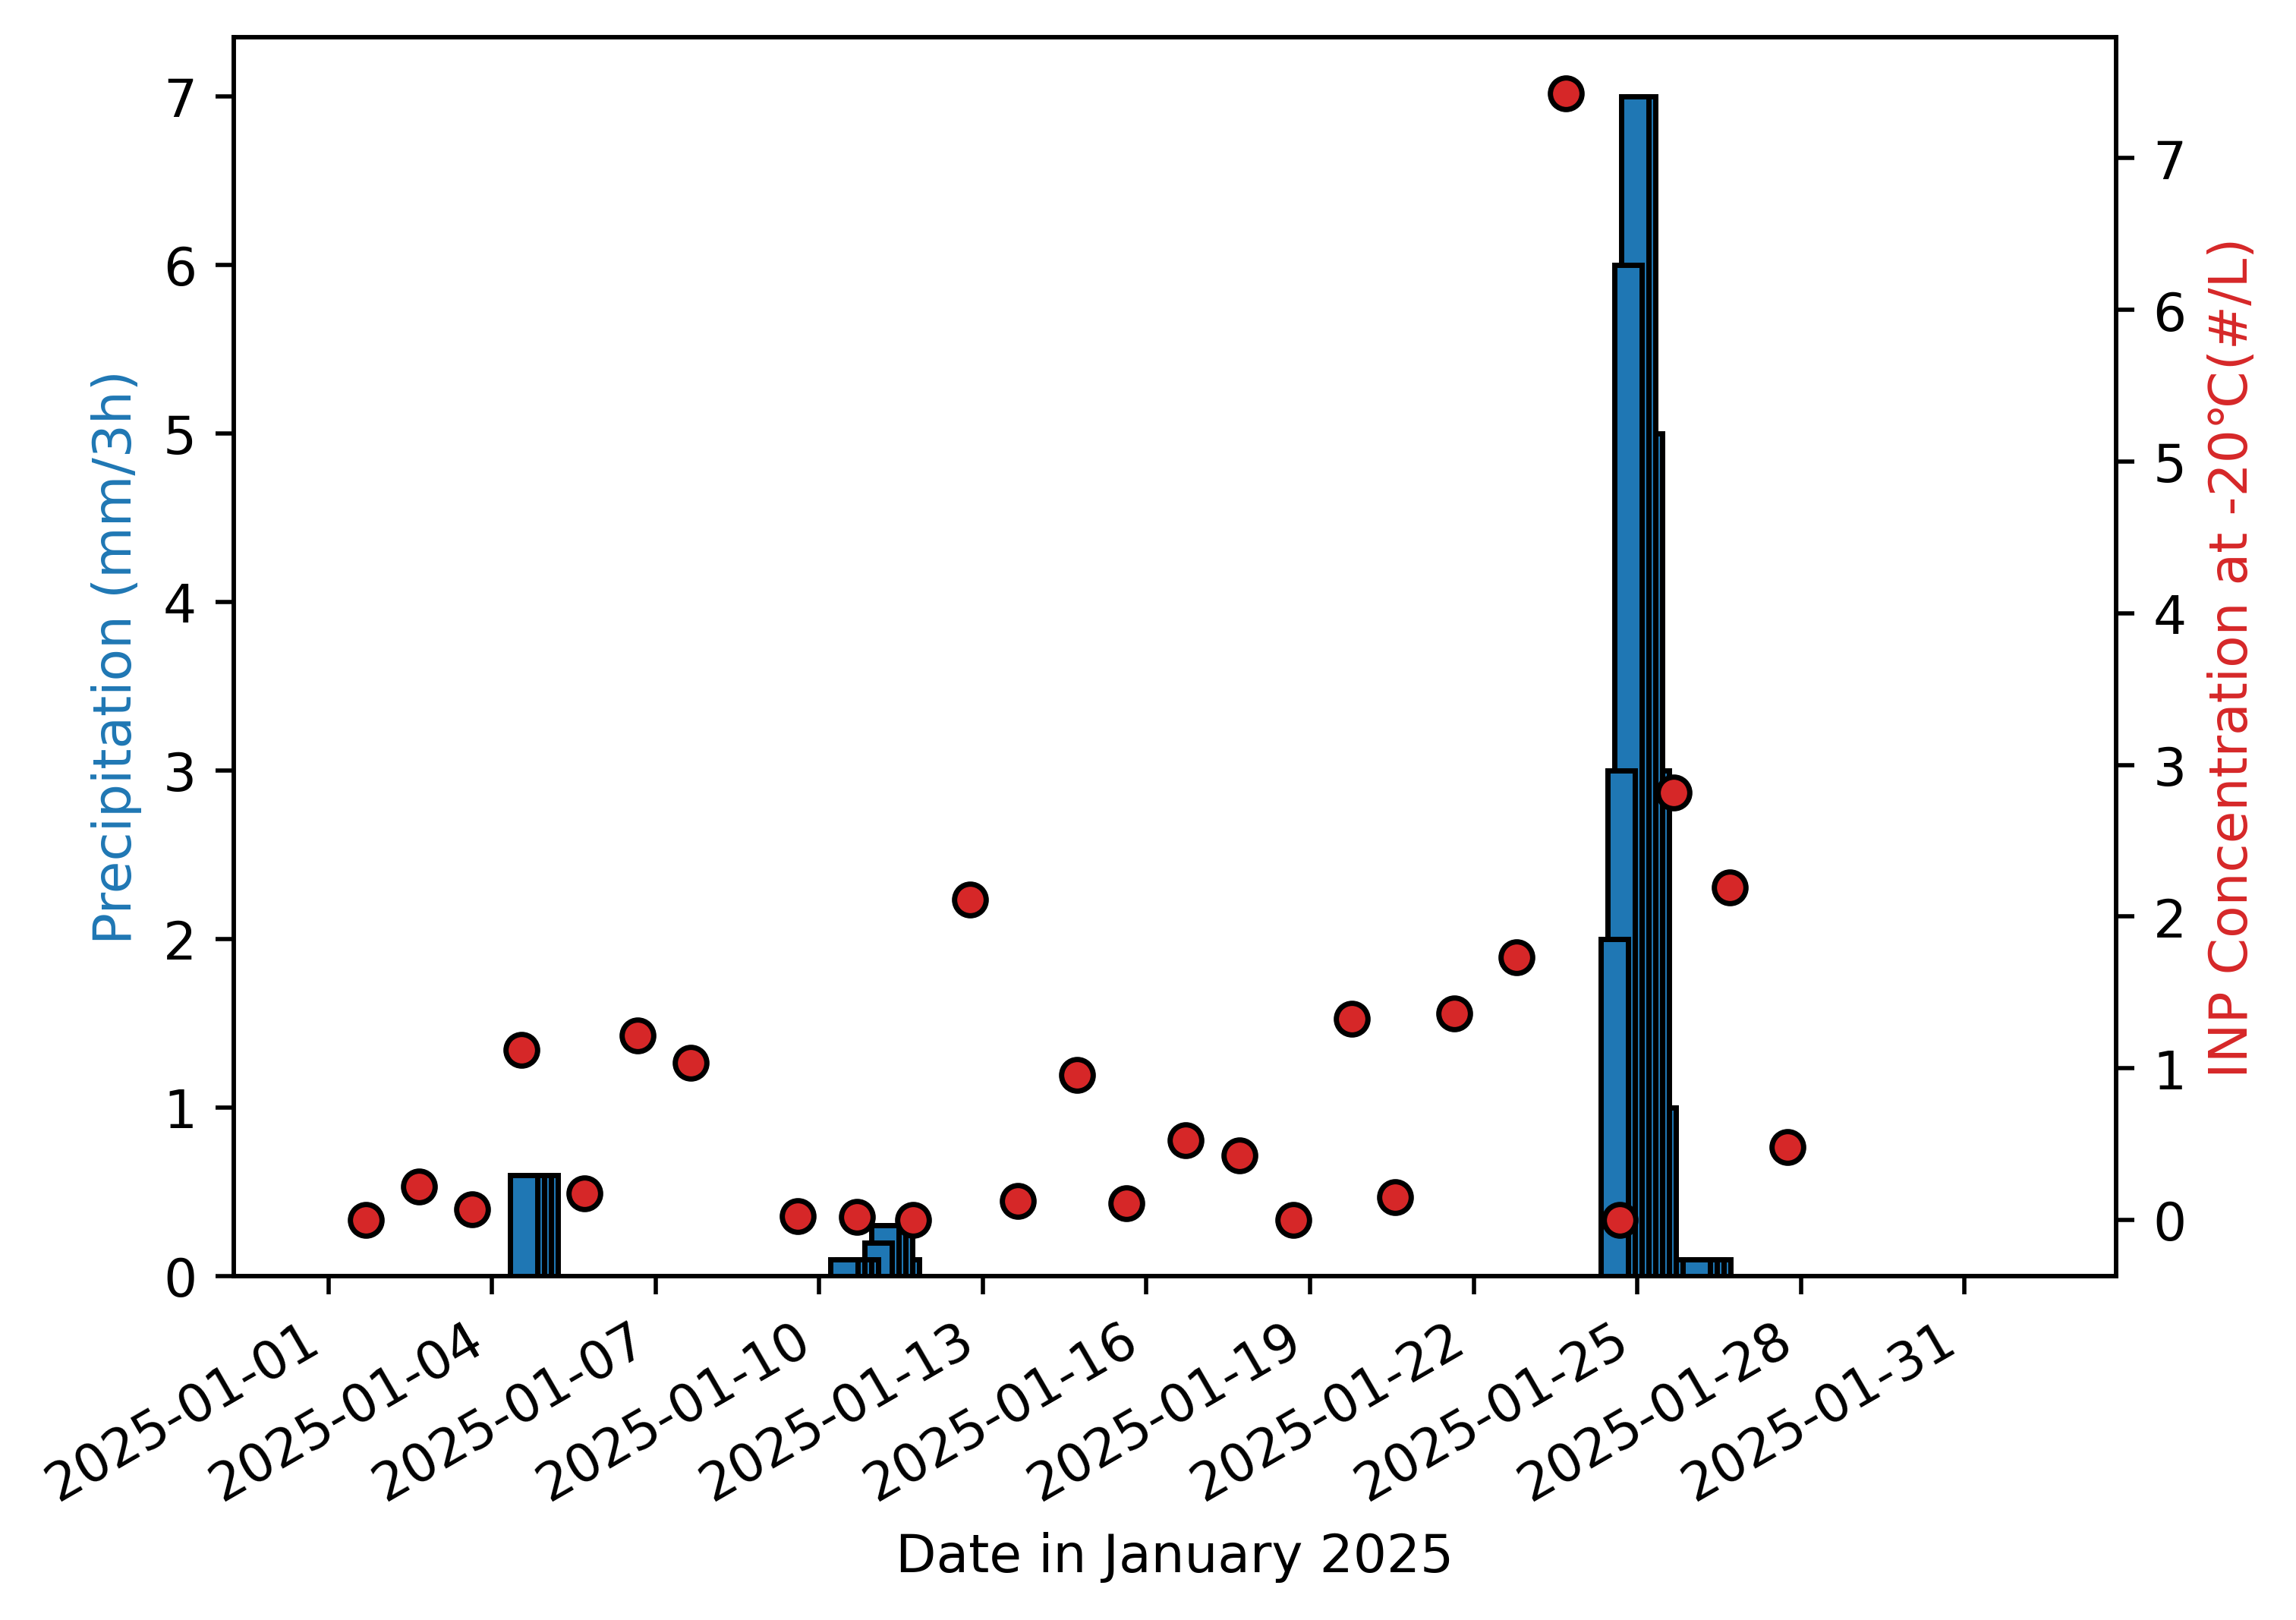

In [25]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -20℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-20_jan_linear.png")###

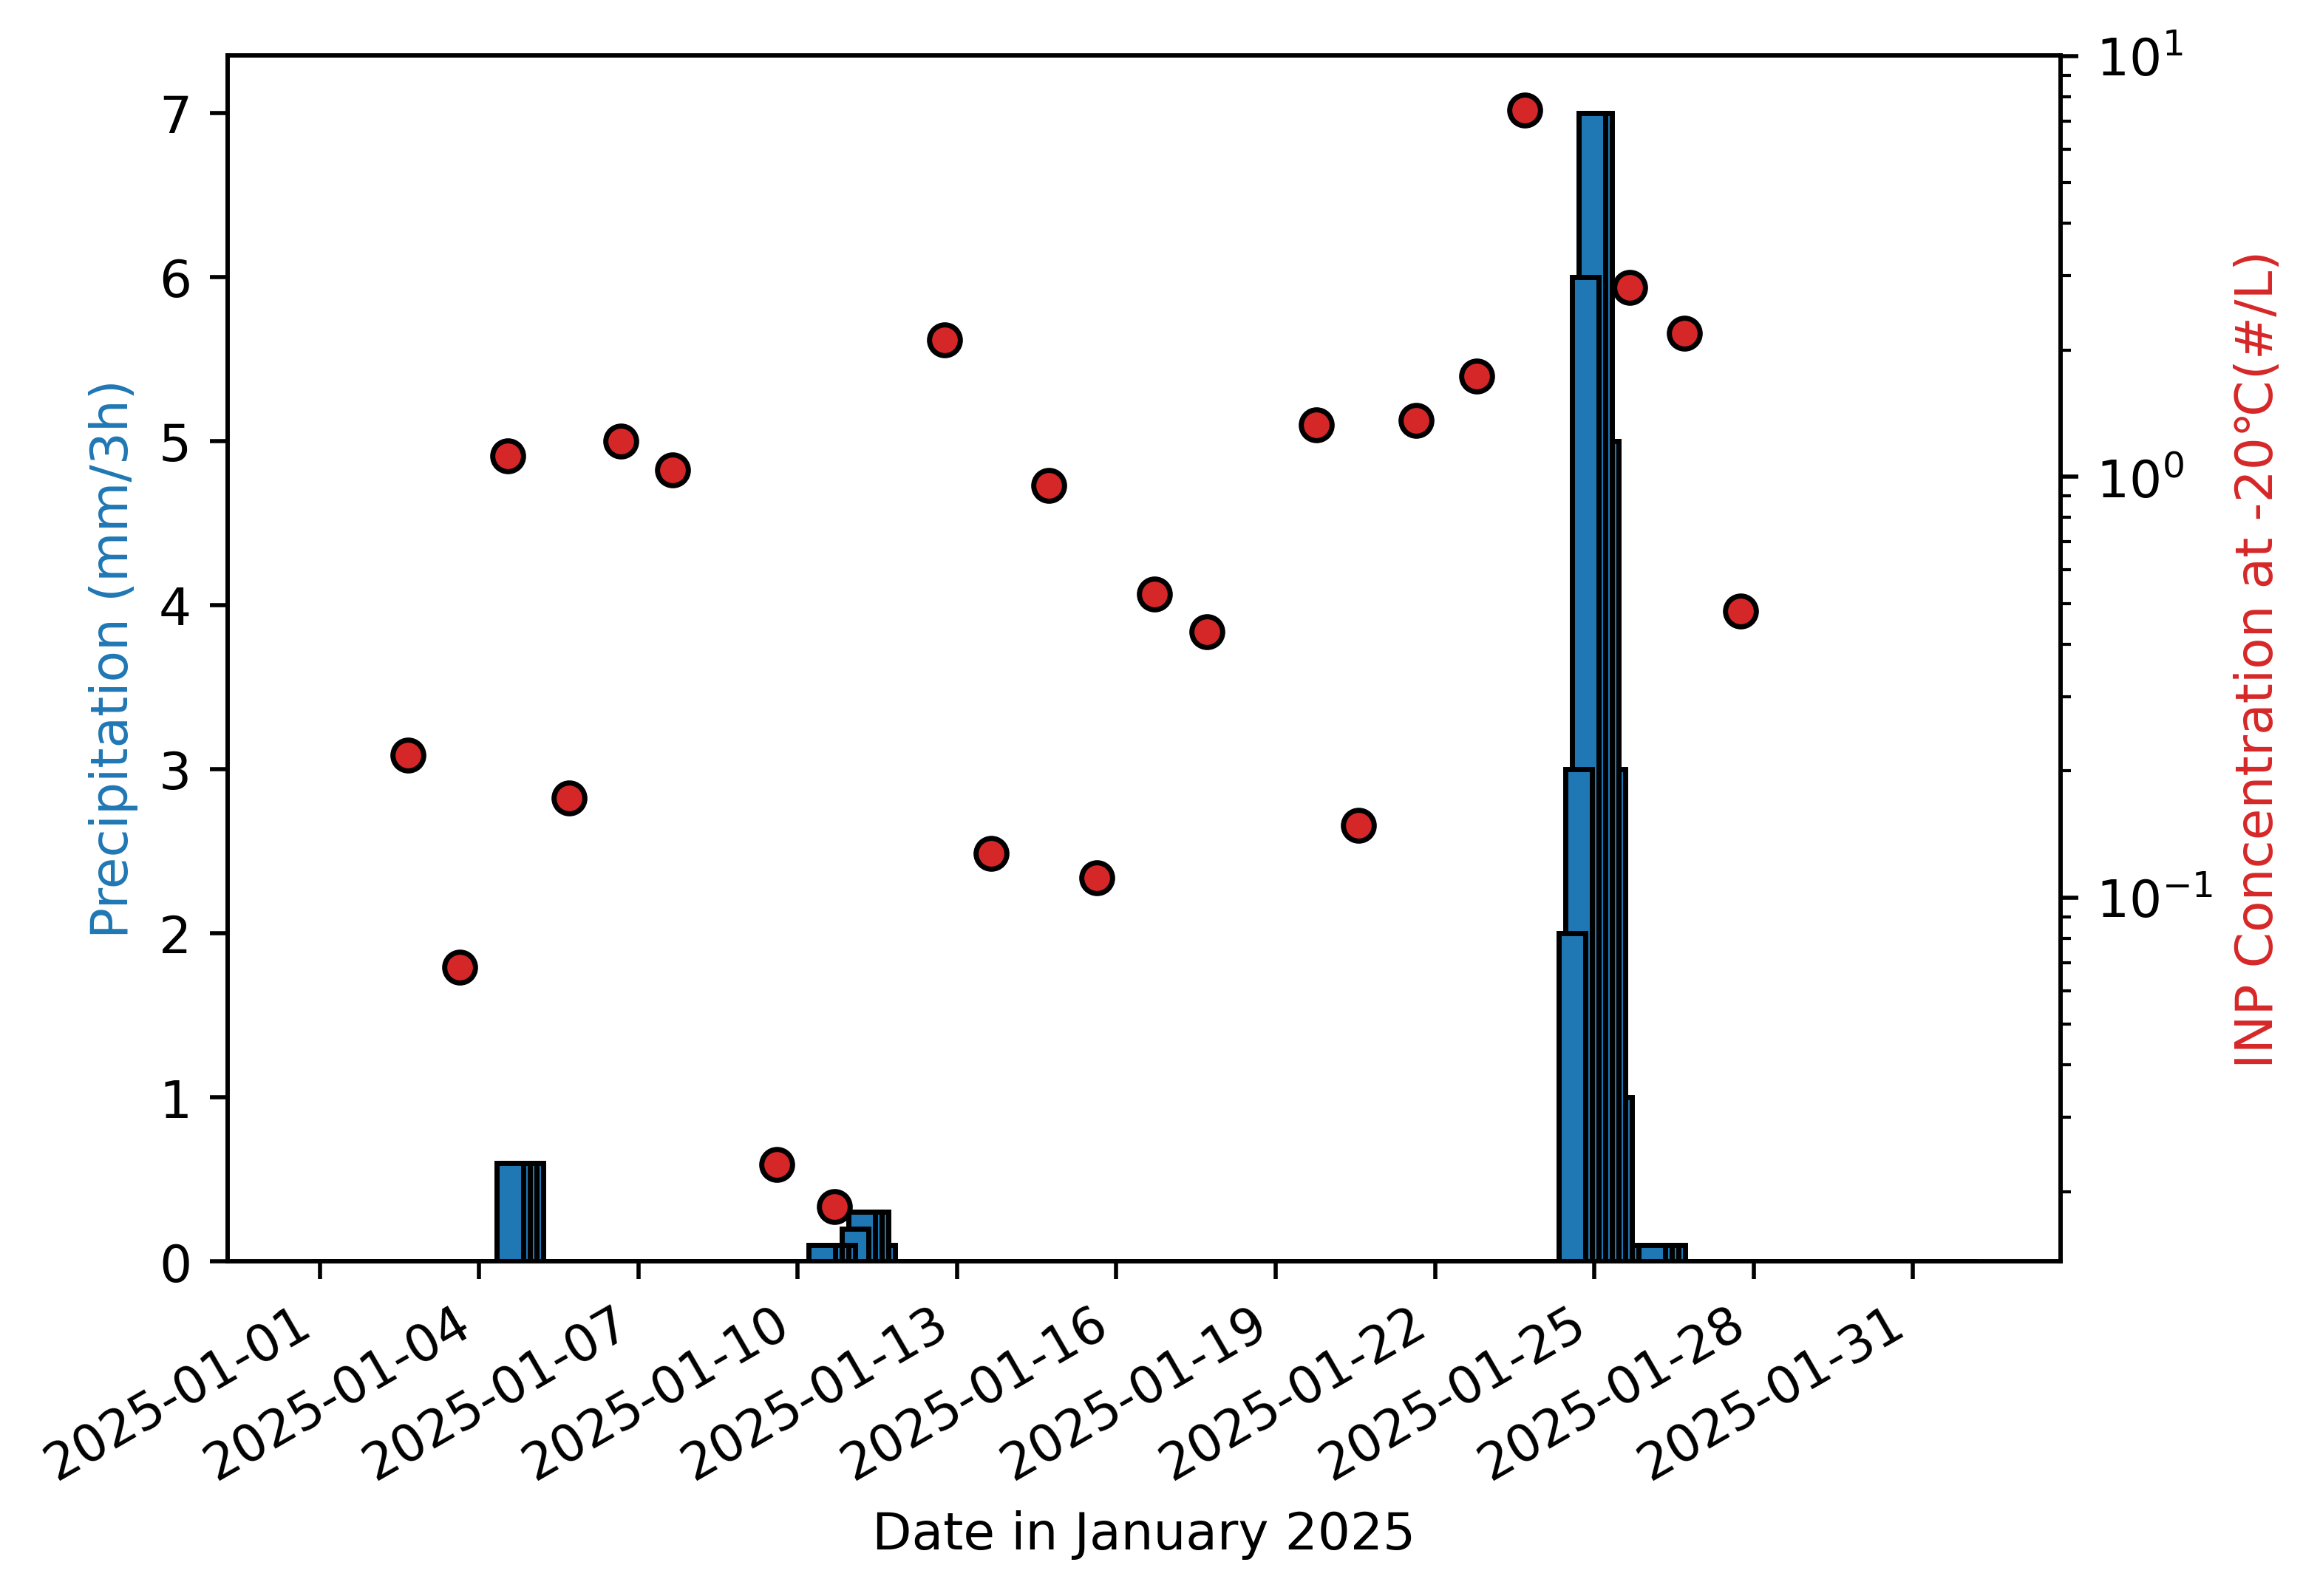

In [26]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -20℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-20_jan_log.png")###

## -25degC

In [27]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')

    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -25degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-25.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-25.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(N_inp_sam, N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index[0]])
    all_INP.append(N_inp_avg_net[N_inp_avg_net.index[0]])

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

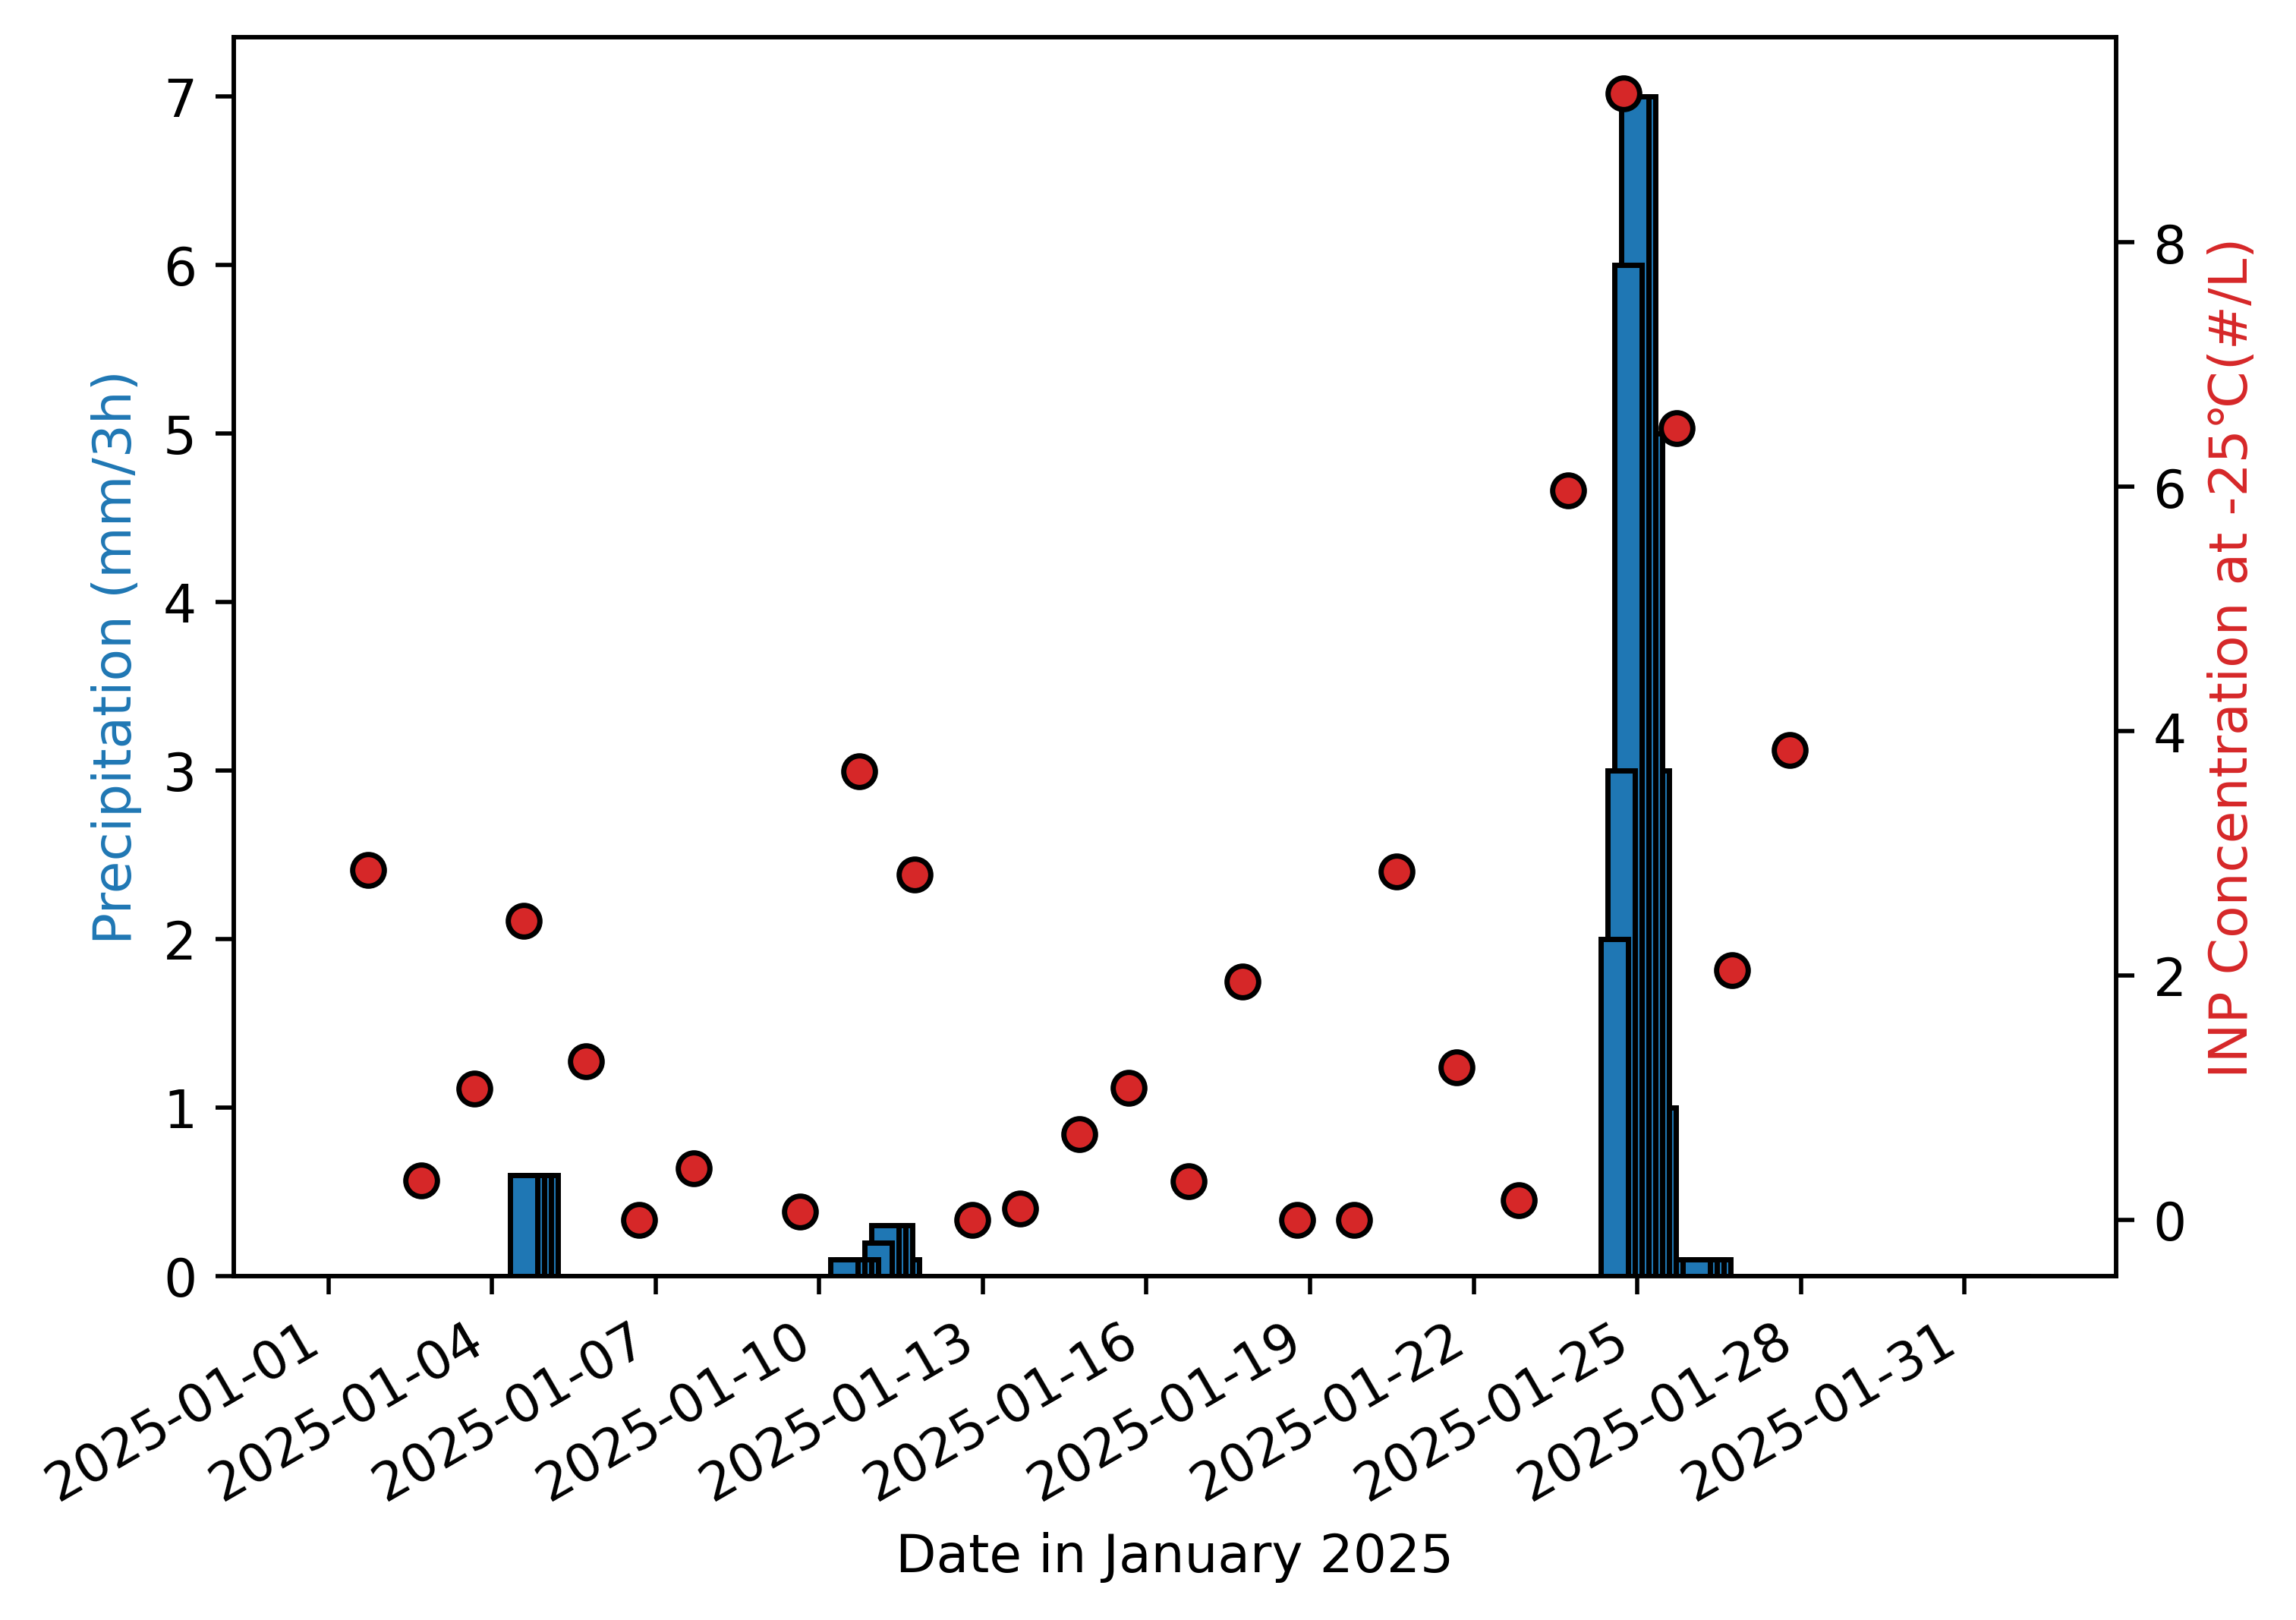

In [29]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -25℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-25_jan_linear.png")###

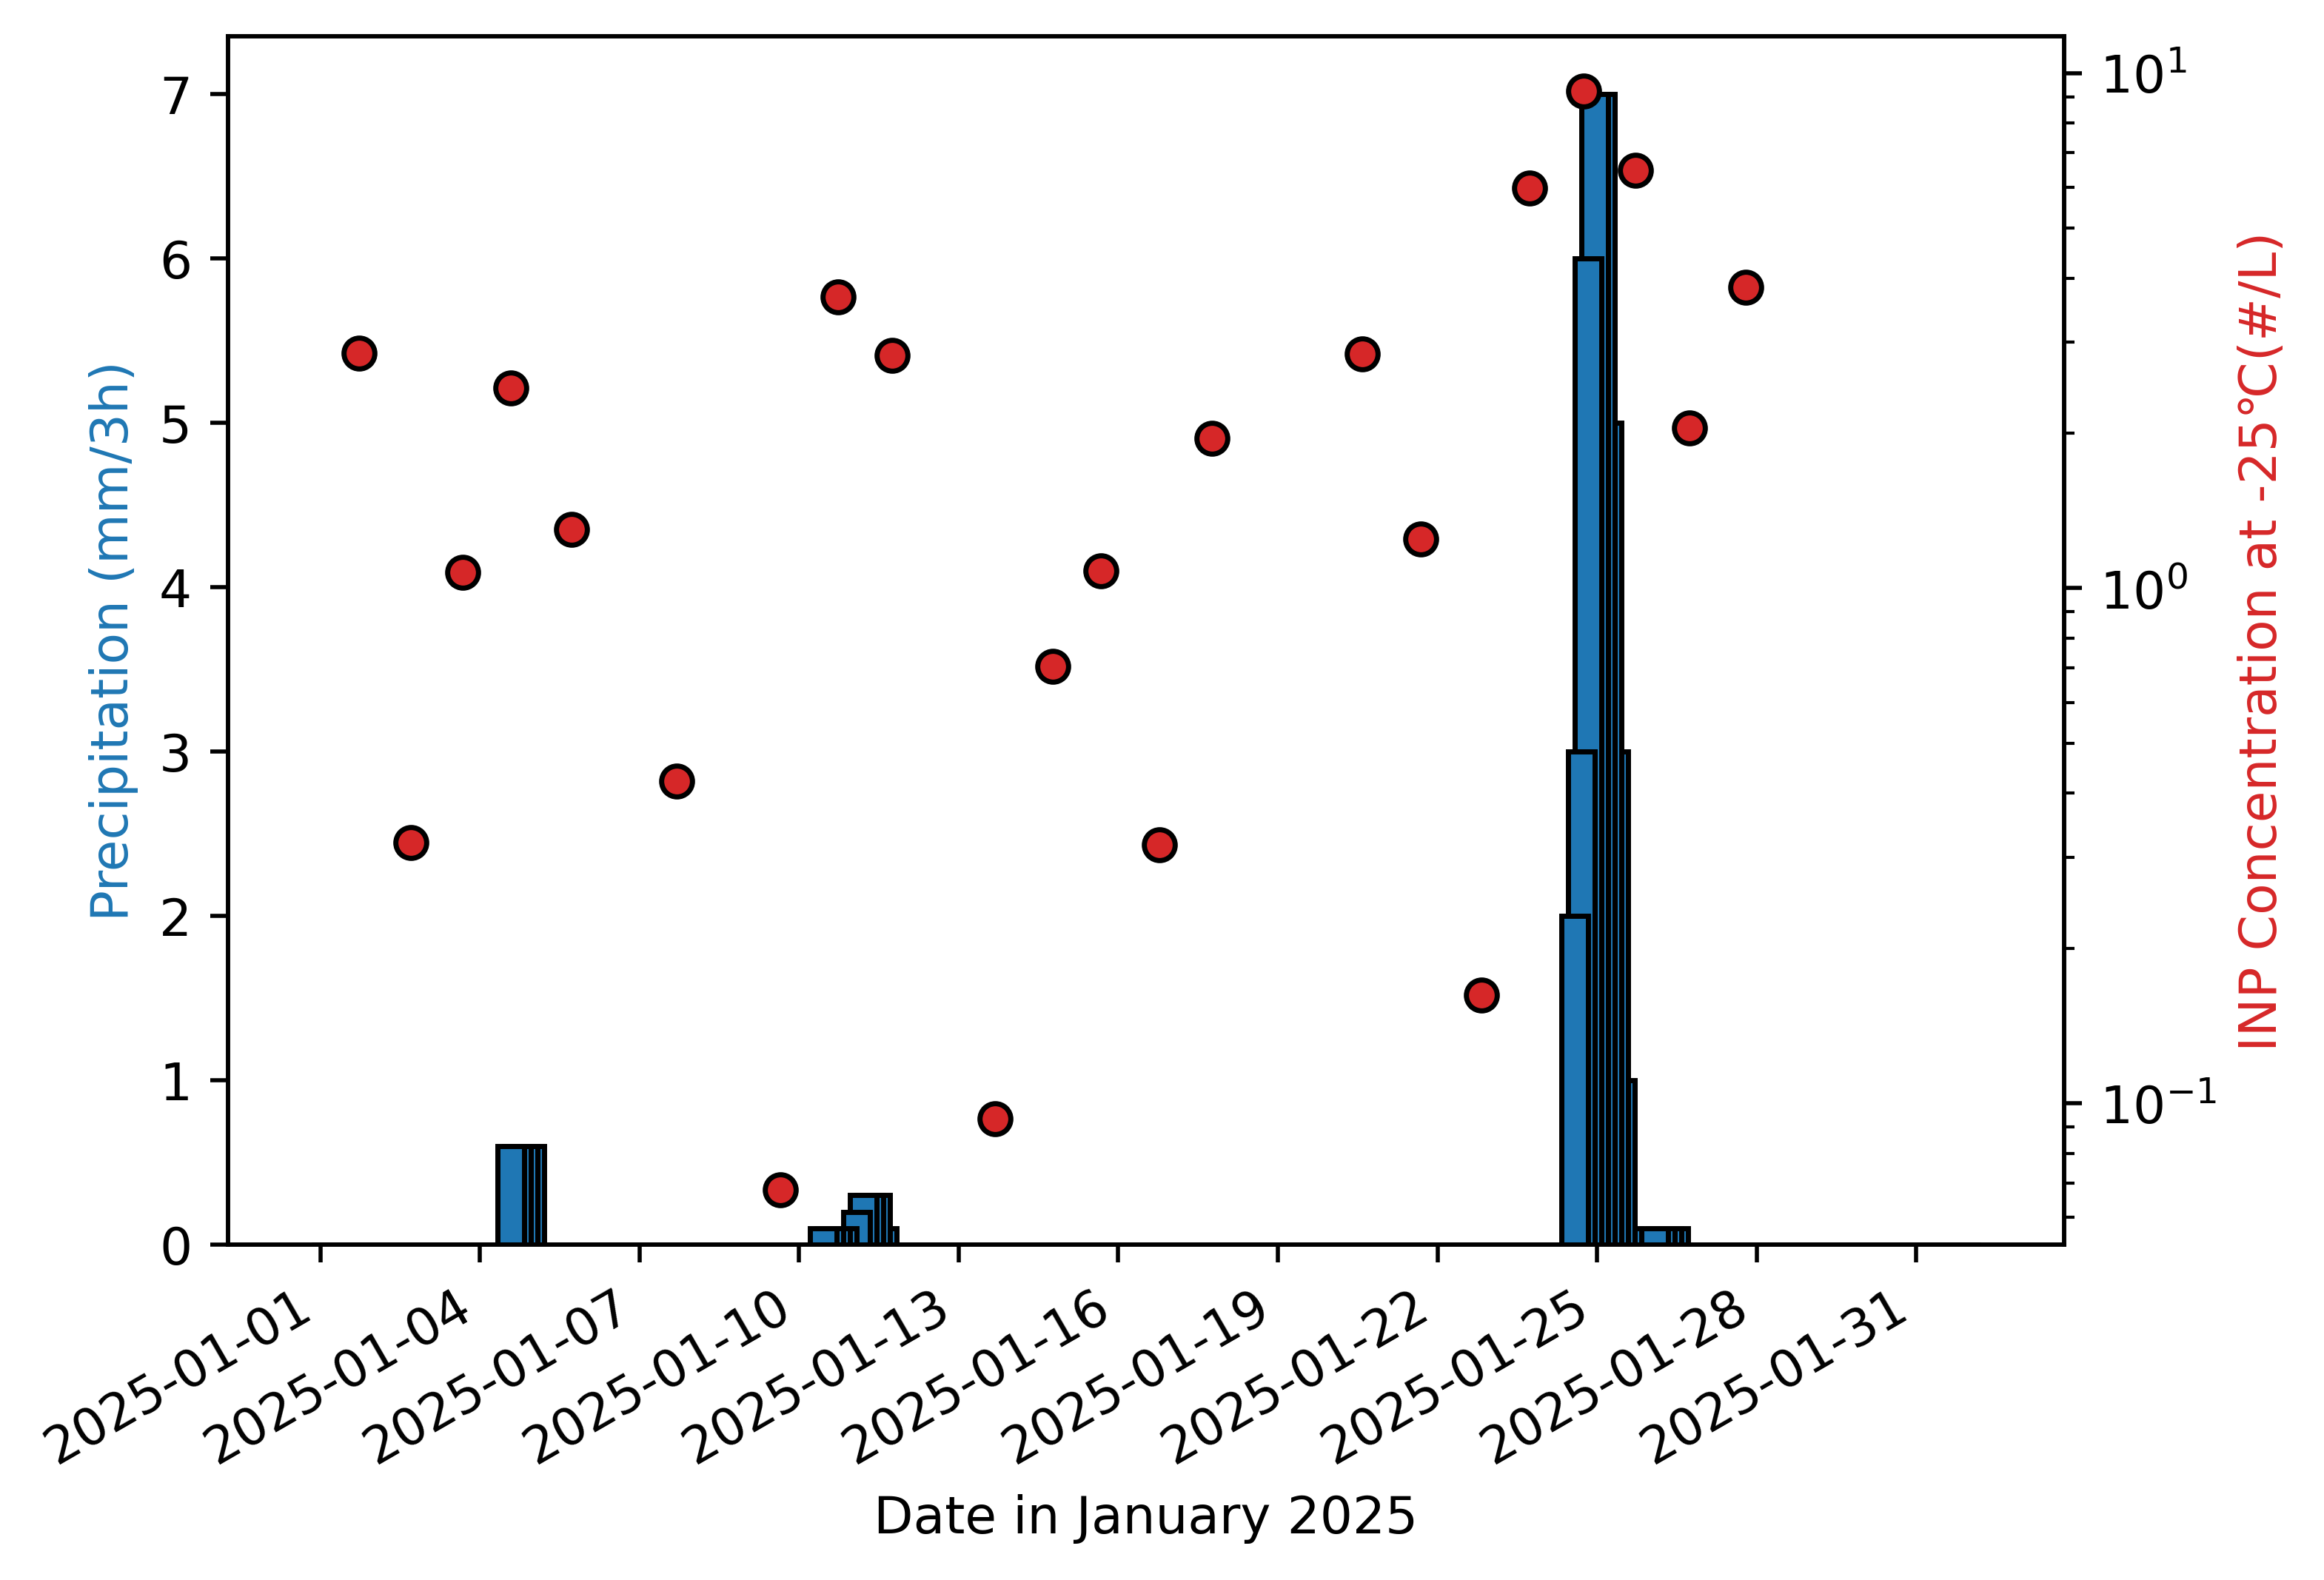

In [30]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -25℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-25_jan_log.png")###

## -30degC

In [31]:
## 可视化数据的提取与处理
### 处理INP数据
p = Path(r"D:\Coding\Data\Lanzhou_cfdc")
all_dates = []
all_INP = []

### 数据处理, 合并多天INP数据, 保存为列表格式
for file in p.glob("data_202501*.csv"):
    data = pd.read_csv(file).dropna(subset=['Lamina Average T [C]'])
    #### 确定日期
    base_date = pd.to_datetime(file.stem.split('_')[1][0:8])
    dt = base_date + pd.to_timedelta(data['Time'], unit='s')

    bac_toggle = data['Background INP avg [#/L] Toggle']
    sam_toggle = data['Sample INP avg [#/L] Toggle']
    #### -30degC下INP浓度提取, 修改此处温度值可选择不同温度下的INP浓度 ####
    N_inp_bac = data['Background INP avg [#/L]'][bac_toggle==True][data['Lamina T Set [C]']==-30.0].reindex(dt.index, fill_value=np.nan)
    N_inp_sam = data['Sample INP avg [#/L]'][sam_toggle==True][data['Lamina T Set [C]']==-30.0].reindex(dt.index, fill_value=np.nan)
    #### 计算净INP浓度
    N_inp_avg_net = compute_net(N_inp_sam, N_inp_bac)
    #### 保存为列表格式
    all_dates.append(dt[N_inp_avg_net.index[0]])
    all_INP.append(N_inp_avg_net[N_inp_avg_net.index[0]])

### 合并所有INP数据, 创建DataFrame(INP是其中一列)
df_inp = pd.DataFrame({'Date': all_dates,
                   'N_inp_net': all_INP})
### 处理降水数据
data_prp = pd.read_csv(r"D:\Coding\Data\Lanzhou_precipitation\rp5.ru\52983.01.02.2024.11.11.2025.1.0.0.en.utf8.00000000.csv"
    , skiprows=6
    , sep=";"
    , index_col=False
)
date = pd.to_datetime(data_prp['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
#### 选择2025年1月的数据, 修改此处时间可选择时间序列的起止时间 ####
data_prp_selected = data_prp[(date >= '2025-01-01') & (date < '2025-02-01')]
### 读取日期数据, 为绘图做准备
x_inp = df_inp['Date']
x_prp = pd.to_datetime(data_prp_selected['Local time in Lanzhou'], format='%d.%m.%Y %H:%M')
### 读取INP数据, 为绘图做准备
y_inp = df_inp['N_inp_net']
### 读取降水数据, 为绘图做准备
y_prp = data_prp_selected['RRR'].replace('No precipitation', 0).astype(float)

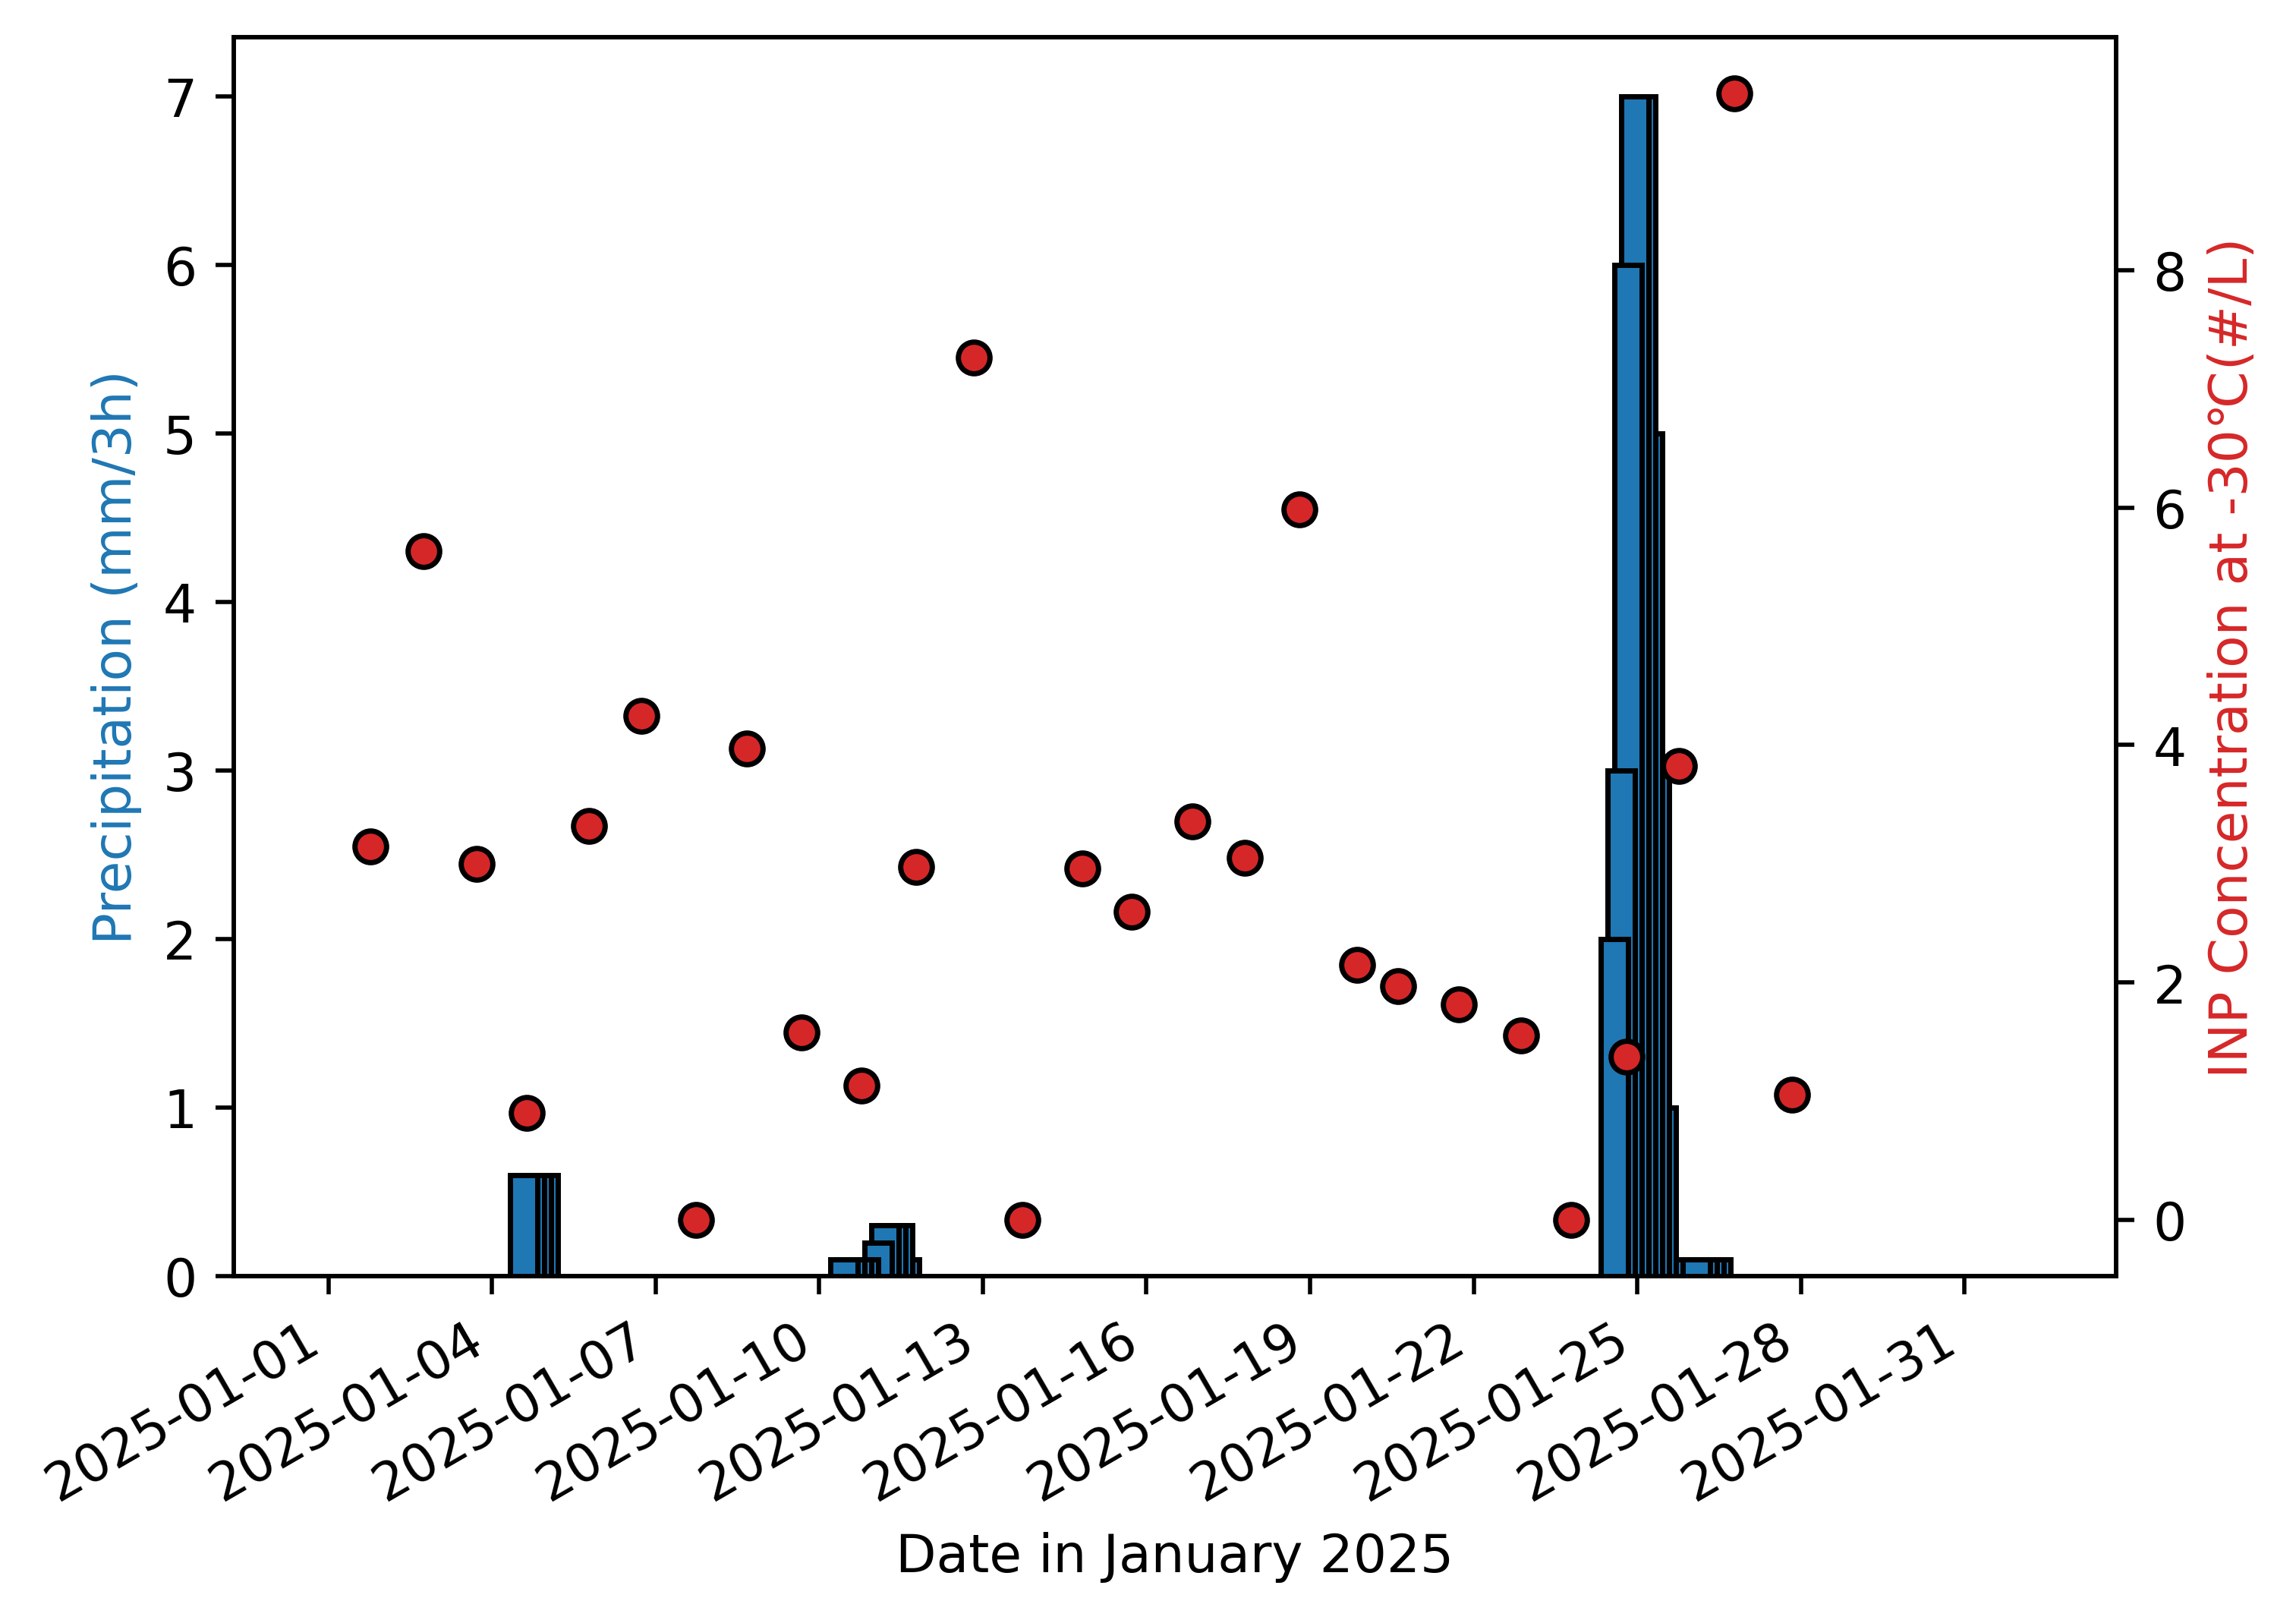

In [33]:
## 可视化绘图: 线性坐标

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_ylabel('INP Concentration at -30℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-30_jan_linear.png")###

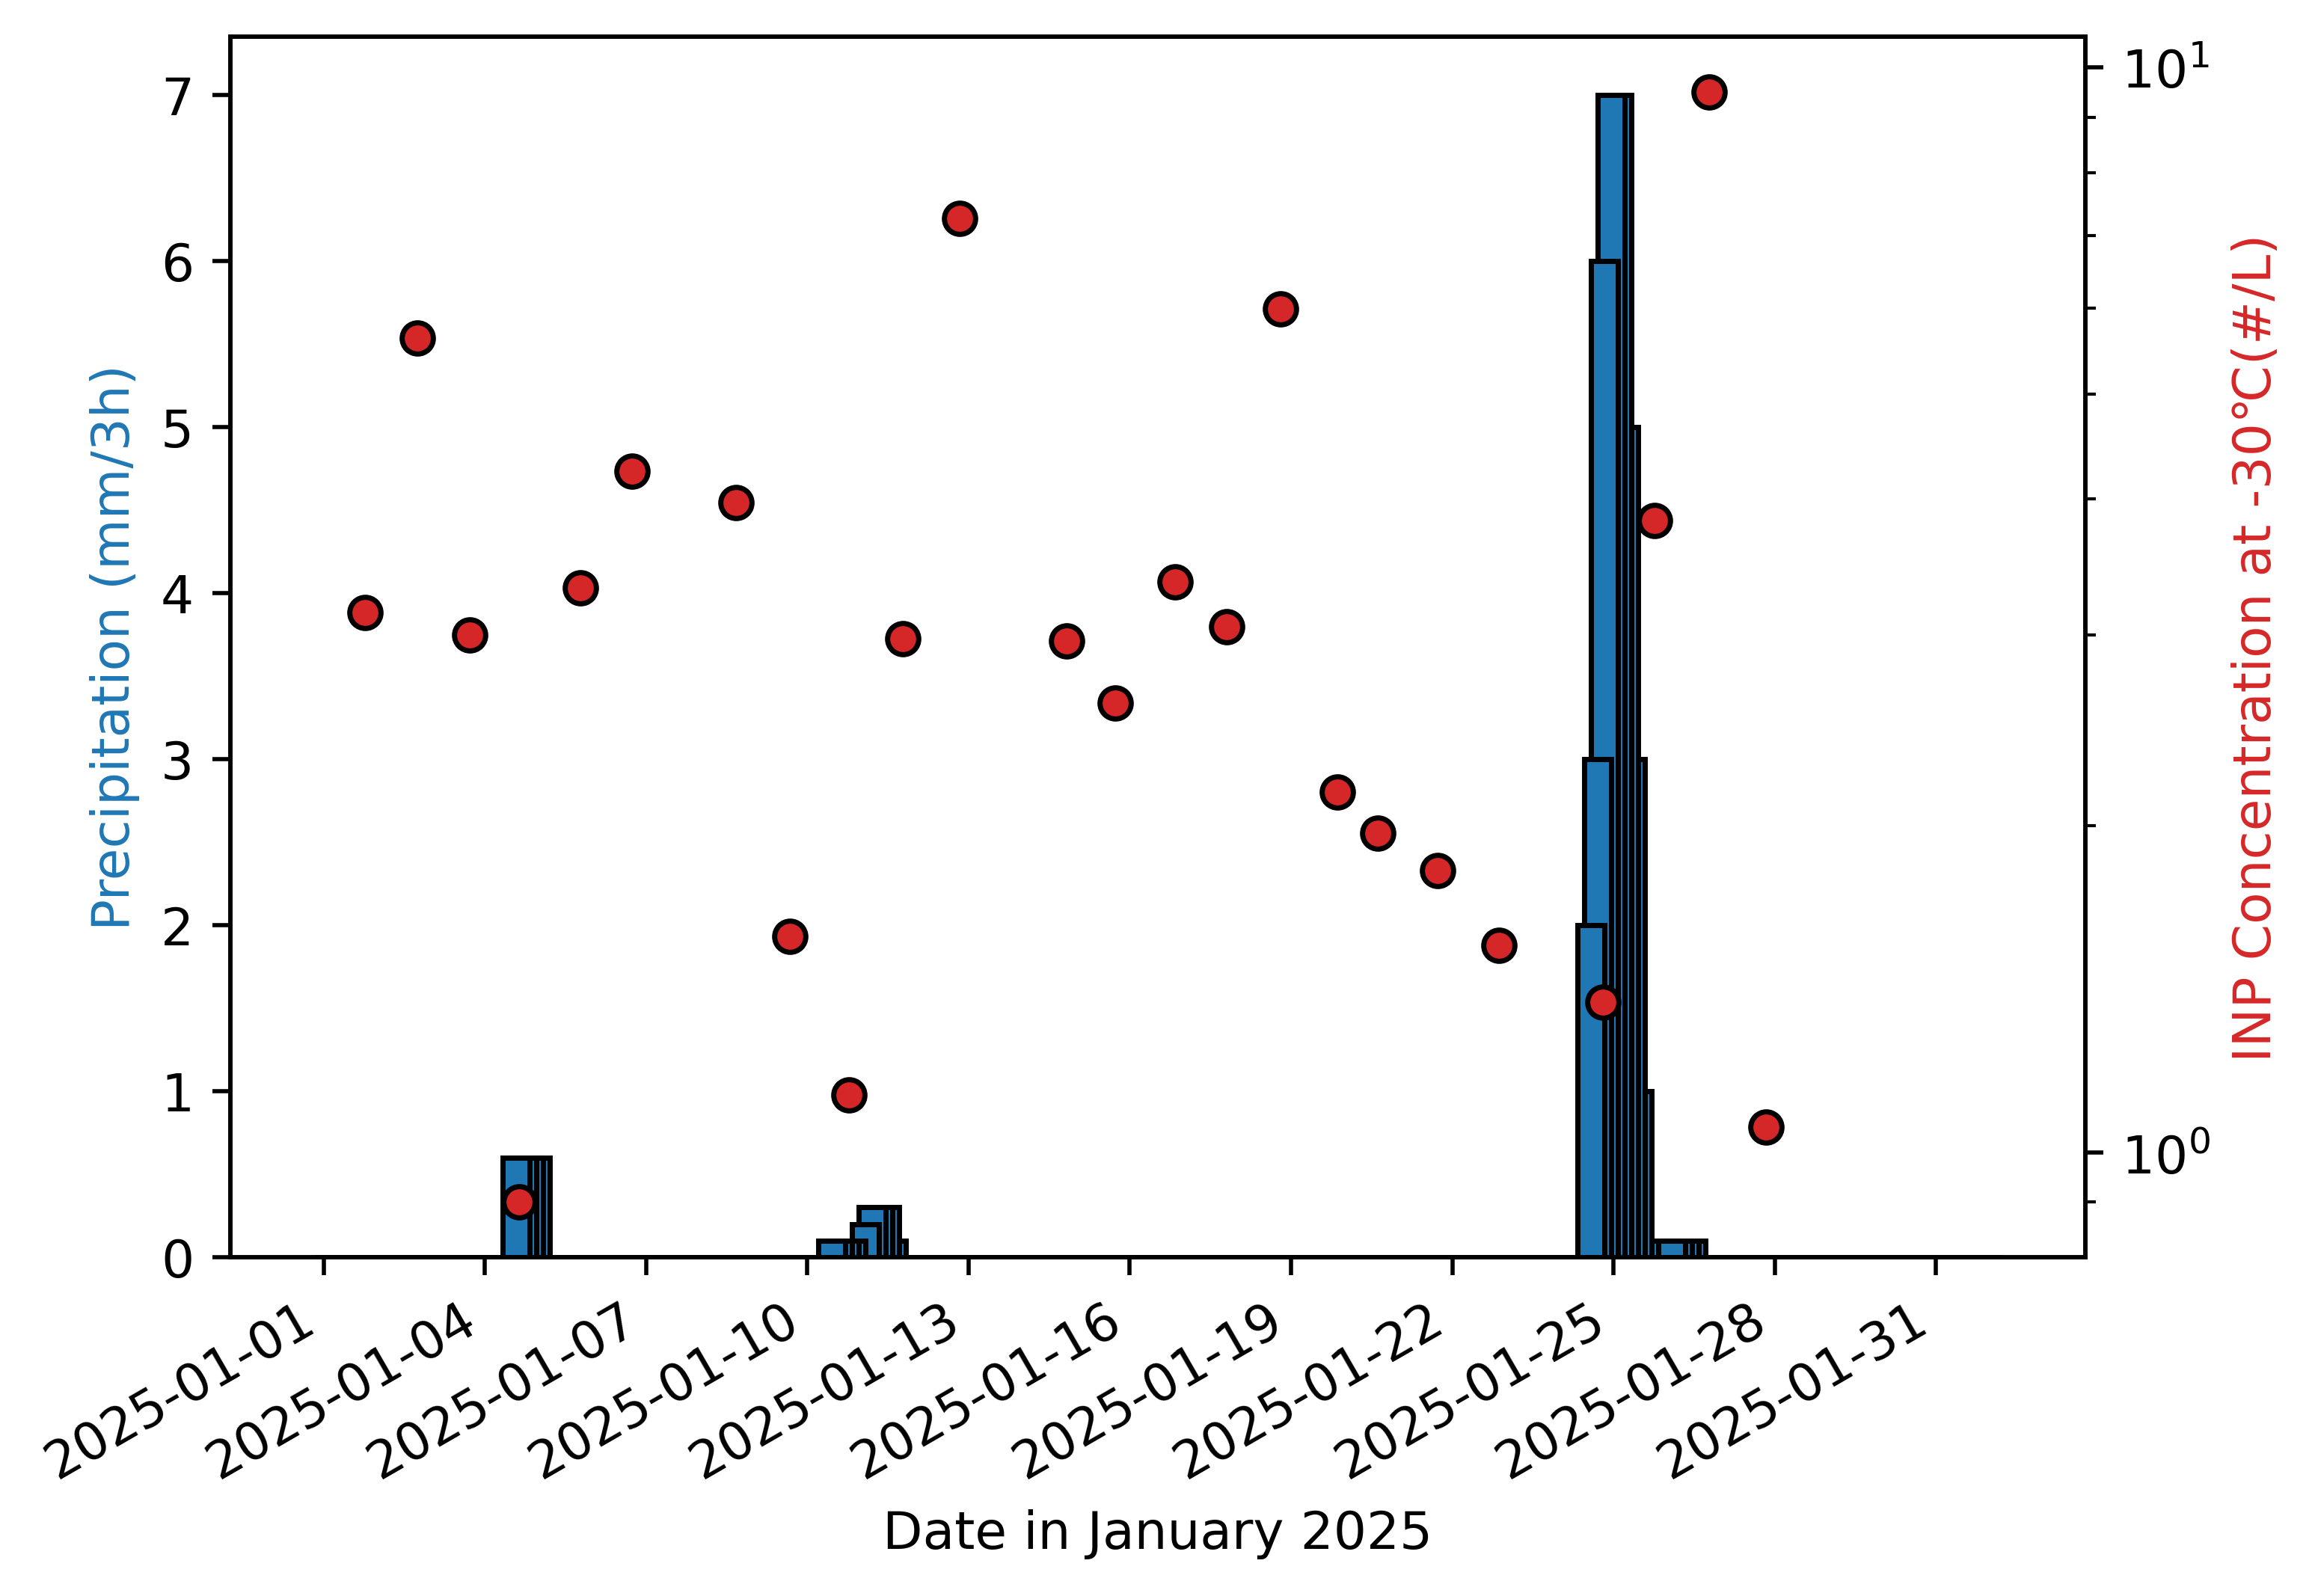

In [35]:
## 可视化绘图: log坐标系

fig = plt.figure(dpi=500)
ax1 = fig.add_subplot(111)

ax1.bar(x_prp, y_prp, color='tab:blue', edgecolor='k', width=0.5)
ax2 = ax1.twinx()
ax2.scatter(x_inp, y_inp, color='tab:red', edgecolor='k')
### x轴的设置
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))# 每隔3天设置一个主刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()# 自动旋转日期标记
ax1.set_xlabel('Date in January 2025')###
### y轴的设置
ax1.set_ylabel('Precipitation (mm/3h)', color='tab:blue')
ax2.set_yscale('log')
ax2.set_ylabel('INP Concentration at -30℃(#/L)', color='tab:red')###
### 保存图片
plt.savefig(r"D:\Coding\master0_2025\Lanzhou_cfdc\INP-30_jan_log.png")###